<a href="https://colab.research.google.com/github/victor22-gif/victor-career-website/blob/main/Stock_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import yfinance as yf

In [4]:
# Data collection
def collect_stock_data(ticker="AAPL", start_date="2020-01-01"):
    """
    Collect historical stock data from Yahoo Finance

    Parameters:
    - ticker: Stock symbol
    - start_date: Start date for data collection

    Returns:
    - DataFrame with stock data
    """
    # Download stock data
    stock_data = yf.download(ticker, start=start_date)

    # Reset index to make date a column
    stock_data.reset_index(inplace=True)

    return stock_data

In [5]:
# Feature Engineering
def create_features(df):
    """
    Create additional features for prediction

    Parameters:
    - df: Input DataFrame

    Returns:
    - DataFrame with new features
    """
    # Create lag features (previous day's prices)
    df['Prev_Close'] = df['Close'].shift(1)
    df['Prev_Volume'] = df['Volume'].shift(1)

    # Create rolling features
    df['MA_5'] = df['Close'].rolling(window=5).mean()
    df['MA_20'] = df['Close'].rolling(window=20).mean()

    # Calculate daily returns
    df['Daily_Return'] = df['Close'].pct_change()

    # Drop rows with NaN values
    df.dropna(inplace=True)

    return df

In [6]:
# Prepare Data for modeling
def prepare_data(df, train_size=0.8):
    """
    Prepare data for machine learning

    Parameters:
    - df: Input DataFrame with features
    - train_size: Proportion of data to use for training (default 0.8)

    Returns:
    - X (features), y (target), train and test splits
    """
    # Select features
    features = ['Prev_Close', 'Prev_Volume', 'MA_5', 'MA_20', 'Daily_Return']
    X = df[features]
    y = df['Close']

    # Calculate split index based on train_size
    split_index = int(len(X) * train_size)

    X_train = X[:split_index]
    X_test = X[split_index:]
    y_train = y[:split_index]
    y_test = y[split_index:]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [7]:
# Train model
def train_model(X_train, y_train):
    """
    Train a linear regression model

    Parameters:
    - X_train: Scaled training features
    - y_train: Training target values

    Returns:
    - Trained model
    """
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

In [8]:
# Evaluate model
def evaluate_model(model, X_test, y_test):
    """
    Evaluate model performance

    Parameters:
    - model: Trained model
    - X_test: Scaled test features
    - y_test: Test target values

    Returns:
    - Predictions and performance metrics
    """
    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return y_pred, mse, r2

In [9]:
# Visualize Results
def plot_results(y_test, y_pred):
    """
    Plot actual vs predicted stock prices

    Parameters:
    - y_test: Actual stock prices
    - y_pred: Predicted stock prices
    """
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.values, label='Actual Prices', color='blue')
    plt.plot(y_pred, label='Predicted Prices', color='red')
    plt.title('Stock Price: Actual vs Predicted')
    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()

[*********************100%***********************]  1 of 1 completed


Mean Squared Error: 1.4388132702569358
R-squared Score: 0.9974943482661717


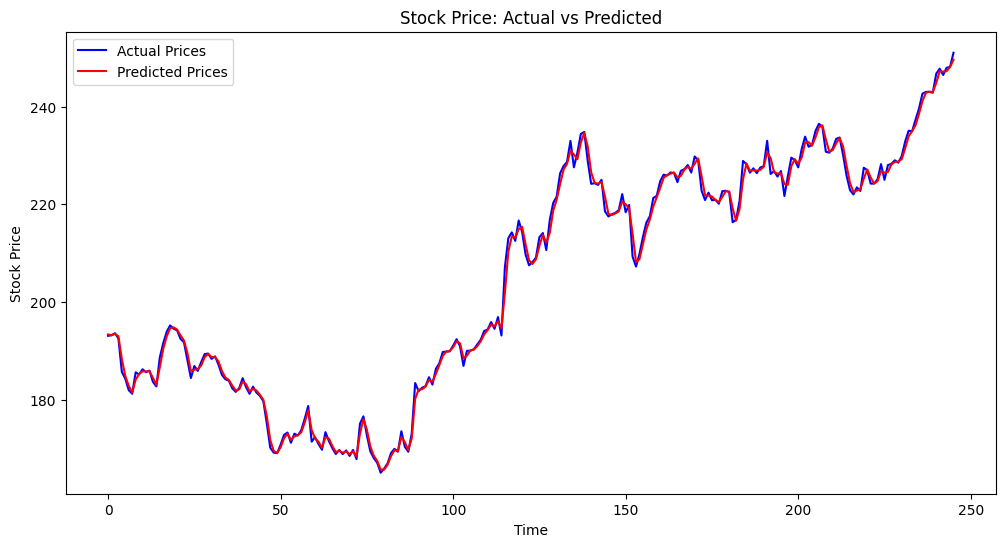

In [10]:
# Main Execution
def main():
    # Collect stock data
    stock_data = collect_stock_data()

    # Create features
    featured_data = create_features(stock_data)

    # Prepare data with 80/20 split
    X_train, X_test, y_train, y_test, scaler = prepare_data(featured_data, train_size=0.8)

    # Train model
    model = train_model(X_train, y_train)

    # Evaluate model
    y_pred, mse, r2 = evaluate_model(model, X_test, y_test)

    # Print performance metrics
    print(f"Mean Squared Error: {mse}")
    print(f"R-squared Score: {r2}")

    # Visualize results
    plot_results(y_test, y_pred)

    return model

# Run the main script
if __name__ == '__main__':
    main()